In [34]:
%pip install torch torchvision opencv-python matplotlib scikit-learn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [36]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [37]:
train_dataset = datasets.ImageFolder("dataset/train", transform=transform)
val_dataset = datasets.ImageFolder("dataset/val", transform=transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=transform)

In [38]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [39]:
print(train_dataset.class_to_idx)

{'negative': 0, 'positive': 1}


In [40]:
model = torchvision.models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 2)

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

weights = torch.tensor([2.7, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [42]:
for epoch in range(10):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 10.084915159270167
Epoch: 2 Loss: 3.290692508686334
Epoch: 3 Loss: 1.333197119878605
Epoch: 4 Loss: 1.7068410138599575
Epoch: 5 Loss: 0.9794571397360414
Epoch: 6 Loss: 0.8997287960955873
Epoch: 7 Loss: 0.9456823677755892
Epoch: 8 Loss: 1.2831908808730077
Epoch: 9 Loss: 0.9853439159924164
Epoch: 10 Loss: 0.3527035451552365


In [43]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation accuracy:", correct/total)

Validation accuracy: 0.9732142857142857


In [44]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92        30
           1       0.99      0.95      0.97        82

    accuracy                           0.96       112
   macro avg       0.93      0.96      0.94       112
weighted avg       0.96      0.96      0.96       112



In [45]:
torch.save(model.state_dict(), "glaucoma_model.pth")

In [46]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

y_scores = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        y_scores.extend(probs[:,1].numpy())

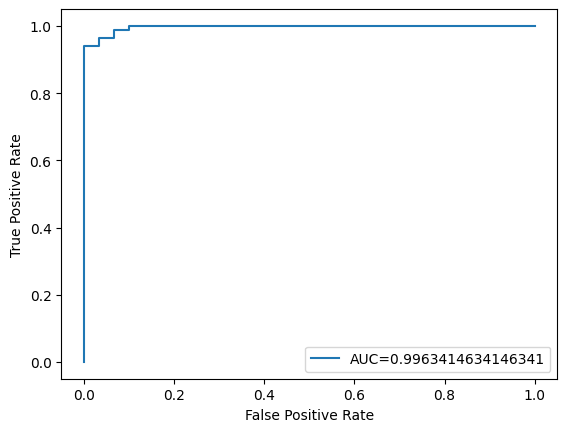

In [47]:
from matplotlib import pyplot as plt


fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [48]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true, y_pred)
print("AUC:", auc)

AUC: 0.9589430894308943


GRAD-CAM

In [49]:
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [51]:
model = models.resnet18()

model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("glaucoma_model.pth"))

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [52]:
target_layer = model.layer4[-1]

In [58]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img = Image.open("dataset/test/negative/274_0.jpg").convert("RGB")

input_tensor = transform(img).unsqueeze(0)

In [59]:
img_np = np.array(img.resize((224,224))) / 255.0

In [60]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)

cam_image = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

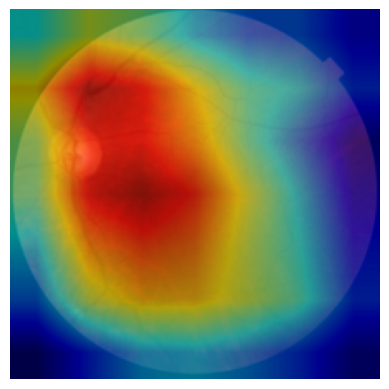

In [61]:
plt.imshow(cam_image)
plt.axis("off")
plt.show()